In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/bim_ai_civil_engineering_dataset.csv')

In [3]:
df

,Project_ID,Project_Type,Location,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,...,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level
0,PJT_1,Tunnel,Houston,2020-01-01,2021-09-26,12260784,1.505450e+07,2.793720e+06,699,813.914852,...,25202.994687,244.843310,6602,76.300184,8,6.192198,52.988330,0,95.006343,High
1,PJT_2,Dam,Houston,2020-01-02,2020-12-06,2369277,3.507054e+06,1.137777e+06,269,384.118221,...,49066.172542,263.123025,7121,63.527671,5,2.134473,50.885745,0,25.294824,Low
2,PJT_3,Building,Houston,2020-01-03,2021-12-05,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,...,48192.547163,608.985023,9956,47.099444,2,3.113728,93.905836,0,97.478830,Medium
3,PJT_4,Dam,Houston,2020-01-04,2022-04-12,24499306,2.946966e+07,4.970354e+06,809,974.565655,...,19811.151750,673.574344,3725,86.846394,5,4.070101,90.454316,1,95.098131,High
4,PJT_5,Dam,Seattle,2020-01-05,2022-02-12,1749971,2.329338e+06,5.793670e+05,354,347.990127,...,44866.565169,765.476122,4368,61.827163,6,2.759351,78.391069,0,43.624985,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PJT_996,Road,New York,2022-09-22,2025-02-06,3570115,4.125885e+06,5.557696e+05,415,534.336045,...,21590.484073,538.246642,6277,52.264226,3,9.550969,99.533743,0,62.388634,High
996,PJT_997,Bridge,Seattle,2022-09-23,2025-01-02,8499066,1.189375e+07,3.394681e+06,513,533.380201,...,5454.068226,811.373725,2780,54.775943,0,7.290482,52.695231,0,86.280354,High
997,PJT_998,Bridge,New York,2022-09-24,2025-02-20,5672412,7.847154e+06,2.174742e+06,528,524.861704,...,36012.075428,924.643754,3413,95.980892,3,5.586417,63.701802,1,66.886580,High
998,PJT_999,Tunnel,Seattle,2022-09-25,2023-05-11,20877714,2.159990e+07,7.221838e+05,277,362.885969,...,49124.313681,449.530190,8750,85.342848,0,2.644200,87.063213,0,24.900514,Low


In [4]:
df.shape

(1000, 28)

In [5]:
df.columns

Index(['Project_ID', 'Project_Type', 'Location', 'Start_Date', 'End_Date',
       'Planned_Cost', 'Actual_Cost', 'Cost_Overrun', 'Planned_Duration',
       'Actual_Duration', 'Schedule_Deviation', 'Vibration_Level',
       'Crack_Width', 'Load_Bearing_Capacity', 'Temperature', 'Humidity',
       'Weather_Condition', 'Air_Quality_Index', 'Energy_Consumption',
       'Material_Usage', 'Labor_Hours', 'Equipment_Utilization',
       'Accident_Count', 'Safety_Risk_Score', 'Image_Analysis_Score',
       'Anomaly_Detected', 'Completion_Percentage', 'Risk_Level'],
      dtype='str')

In [6]:
df[['Planned_Cost', 'Actual_Cost', 'Cost_Overrun']].head(10)

,Planned_Cost,Actual_Cost,Cost_Overrun
0,12260784,1.505450e+07,2.793720e+06
1,2369277,3.507054e+06,1.137777e+06
2,23299783,2.169213e+07,-1.607656e+06
3,24499306,2.946966e+07,4.970354e+06
4,1749971,2.329338e+06,5.793670e+05
5,16711072,2.368935e+07,6.978281e+06
6,47109273,4.746511e+07,3.558336e+05
7,42776934,5.903226e+07,1.625532e+07
8,25527188,3.143990e+07,5.912716e+06
9,5460276,6.213424e+06,7.531479e+05


In [7]:
df[['Planned_Cost', 'Actual_Cost', 'Cost_Overrun']].describe()

,Planned_Cost,Actual_Cost,Cost_Overrun
count,1.000000e+03,1.000000e+03,1.000000e+03
mean,2.641509e+07,3.154108e+07,5.125992e+06
std,1.448576e+07,1.809596e+07,5.931350e+06
min,1.045475e+06,1.180252e+06,-4.648579e+06
25%,1.431013e+07,1.609655e+07,5.810661e+05
50%,2.690860e+07,3.133922e+07,3.326817e+06
75%,3.957029e+07,4.532747e+07,8.665132e+06
max,4.996854e+07,7.251939e+07,2.401229e+07


In [8]:
df[['Planned_Cost', 'Actual_Cost', 'Cost_Overrun']].corr()

,Planned_Cost,Actual_Cost,Cost_Overrun
Planned_Cost,1.000000,0.957756,0.479780
Actual_Cost,0.957756,1.000000,0.711835
Cost_Overrun,0.479780,0.711835,1.000000


In [9]:
df['Calculated_Overrun'] = df['Actual_Cost'] - df['Planned_Cost']

(df['Calculated_Overrun'] - df['Cost_Overrun']).describe()

count    1.000000e+03
mean     1.114456e-10
std      1.967778e-09
min     -7.450581e-09
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.313226e-09
dtype: float64

In [10]:
(df['Calculated_Overrun'] == df['Cost_Overrun']).value_counts()

True     713
False    287
Name: count, dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Project_ID             1000 non-null   str    
 1   Project_Type           1000 non-null   str    
 2   Location               1000 non-null   str    
 3   Start_Date             1000 non-null   str    
 4   End_Date               1000 non-null   str    
 5   Planned_Cost           1000 non-null   int64  
 6   Actual_Cost            1000 non-null   float64
 7   Cost_Overrun           1000 non-null   float64
 8   Planned_Duration       1000 non-null   int64  
 9   Actual_Duration        1000 non-null   float64
 10  Schedule_Deviation     1000 non-null   float64
 11  Vibration_Level        1000 non-null   float64
 12  Crack_Width            1000 non-null   float64
 13  Load_Bearing_Capacity  1000 non-null   float64
 14  Temperature            1000 non-null   float64
 15  Humidity        

In [12]:
df.isnull().sum()

Project_ID               0
Project_Type             0
Location                 0
Start_Date               0
End_Date                 0
Planned_Cost             0
Actual_Cost              0
Cost_Overrun             0
Planned_Duration         0
Actual_Duration          0
Schedule_Deviation       0
Vibration_Level          0
Crack_Width              0
Load_Bearing_Capacity    0
Temperature              0
Humidity                 0
Weather_Condition        0
Air_Quality_Index        0
Energy_Consumption       0
Material_Usage           0
Labor_Hours              0
Equipment_Utilization    0
Accident_Count           0
Safety_Risk_Score        0
Image_Analysis_Score     0
Anomaly_Detected         0
Completion_Percentage    0
Risk_Level               0
Calculated_Overrun       0
dtype: int64

In [13]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Project_ID,1000,1000,PJT_1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Project_Type,1000,5,Bridge,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,1000,5,Los Angeles,211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start_Date,1000,1000,2020-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End_Date,1000,691,2022-12-08,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Planned_Cost,1000.0,NaN,NaN,NaN,26415087.626,14485761.884914,1045475.0,14310133.0,26908602.0,39570293.25,49968538.0
Actual_Cost,1000.0,NaN,NaN,NaN,31541079.260366,18095958.811092,1180251.527639,16096546.659396,31339224.455522,45327468.954879,72519386.550836
Cost_Overrun,1000.0,NaN,NaN,NaN,5125991.634366,5931350.171601,-4648578.917822,581066.139366,3326817.482013,8665132.386436,24012292.061622
Planned_Duration,1000.0,NaN,NaN,NaN,538.62,204.531765,180.0,361.0,535.5,713.0,899.0
Actual_Duration,1000.0,NaN,NaN,NaN,645.560751,269.383932,165.278211,424.252757,635.469136,831.64495,1340.352531


In [14]:
categorical_cols = [
    'Project_Type',
    'Location',
    'Weather_Condition',
    'Risk_Level'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Project_Type
Project_Type
Bridge      210
Tunnel      206
Dam         204
Building    190
Road        190
Name: count, dtype: int64

Location
Location
Los Angeles    211
Seattle        205
New York       205
Houston        190
Chicago        189
Name: count, dtype: int64

Weather_Condition
Weather_Condition
Rainy     216
Snowy     206
Cloudy    201
Stormy    194
Sunny     183
Name: count, dtype: int64

Risk_Level
Risk_Level
High      502
Medium    342
Low       156
Name: count, dtype: int64


In [15]:
df[['Start_Date', 'End_Date']].head(10)

,Start_Date,End_Date
0,2020-01-01,2021-09-26
1,2020-01-02,2020-12-06
2,2020-01-03,2021-12-05
3,2020-01-04,2022-04-12
4,2020-01-05,2022-02-12
5,2020-01-06,2020-09-18
6,2020-01-07,2021-11-25
7,2020-01-08,2021-09-19
8,2020-01-09,2021-03-17
9,2020-01-10,2021-05-23


In [16]:
df[['Start_Date', 'End_Date']].nunique()

Start_Date    1000
End_Date       691
dtype: int64

In [17]:
numeric_cols = [
    'Planned_Cost',
    'Planned_Duration',
    'Actual_Duration',
    'Schedule_Deviation',
    'Vibration_Level',
    'Crack_Width',
    'Load_Bearing_Capacity',
    'Temperature',
    'Humidity',
    'Air_Quality_Index',
    'Energy_Consumption',
    'Material_Usage',
    'Labor_Hours',
    'Equipment_Utilization',
    'Accident_Count',
    'Safety_Risk_Score',
    'Image_Analysis_Score',
    'Anomaly_Detected',
    'Completion_Percentage',
    'Cost_Overrun'
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Planned_Cost,1000.0,2.641509e+07,1.448576e+07,1.045475e+06,1.431013e+07,2.690860e+07,3.957029e+07,4.996854e+07
Planned_Duration,1000.0,5.386200e+02,2.045318e+02,1.800000e+02,3.610000e+02,5.355000e+02,7.130000e+02,8.990000e+02
Actual_Duration,1000.0,6.455608e+02,2.693839e+02,1.652782e+02,4.242528e+02,6.354691e+02,8.316449e+02,1.340353e+03
Schedule_Deviation,1000.0,1.069408e+02,1.103876e+02,-7.913649e+01,2.240240e+01,8.405661e+01,1.739542e+02,4.463525e+02
Vibration_Level,1000.0,1.044378e+00,5.504665e-01,1.074449e-01,5.668824e-01,1.041774e+00,1.535026e+00,1.998975e+00
Crack_Width,1000.0,2.456479e+00,1.427987e+00,1.205023e-03,1.223689e+00,2.419953e+00,3.659447e+00,4.996036e+00
Load_Bearing_Capacity,1000.0,2.660482e+02,1.290861e+02,5.010932e+01,1.539647e+02,2.555037e+02,3.734188e+02,4.985075e+02
Temperature,1000.0,1.711405e+01,1.531382e+01,-9.997095e+00,4.578246e+00,1.719483e+01,2.986844e+01,4.492395e+01
Humidity,1000.0,5.548472e+01,2.024093e+01,2.001686e+01,3.762860e+01,5.574150e+01,7.319260e+01,8.996536e+01
Air_Quality_Index,1000.0,1.747740e+02,7.224729e+01,5.000000e+01,1.127500e+02,1.770000e+02,2.360000e+02,2.990000e+02


In [18]:
df[numeric_cols].corr()['Cost_Overrun'].sort_values(ascending=False)

Cost_Overrun             1.000000
Planned_Cost             0.479780
Load_Bearing_Capacity    0.067201
Air_Quality_Index        0.066589
Material_Usage           0.054209
Safety_Risk_Score        0.038492
Humidity                 0.027677
Anomaly_Detected         0.025696
Completion_Percentage    0.024296
Image_Analysis_Score     0.014355
Vibration_Level          0.003856
Planned_Duration         0.001905
Temperature             -0.011097
Crack_Width             -0.013586
Actual_Duration         -0.015062
Energy_Consumption      -0.023577
Equipment_Utilization   -0.027748
Labor_Hours             -0.033200
Accident_Count          -0.036419
Schedule_Deviation      -0.040288
Name: Cost_Overrun, dtype: float64

In [19]:
check_cols = [
    'Planned_Duration',
    'Actual_Duration',
    'Schedule_Deviation',
    'Completion_Percentage',
    'Planned_Cost',
    'Cost_Overrun'
]

df[check_cols].corr()

,Planned_Duration,Actual_Duration,Schedule_Deviation,Completion_Percentage,Planned_Cost,Cost_Overrun
Planned_Duration,1.000000,0.927587,0.410781,0.003767,-0.004881,0.001905
Actual_Duration,0.927587,1.000000,0.721667,0.009343,-0.012465,-0.015062
Schedule_Deviation,0.410781,0.721667,1.000000,0.015821,-0.021377,-0.040288
Completion_Percentage,0.003767,0.009343,0.015821,1.000000,-0.002922,0.024296
Planned_Cost,-0.004881,-0.012465,-0.021377,-0.002922,1.000000,0.479780
Cost_Overrun,0.001905,-0.015062,-0.040288,0.024296,0.479780,1.000000


In [20]:
df[['Actual_Duration',
    'Planned_Duration',
    'Schedule_Deviation']].head(10)

,Actual_Duration,Planned_Duration,Schedule_Deviation
0,813.914852,699,114.914852
1,384.118221,269,115.118221
2,1081.777915,899,182.777915
3,974.565655,809,165.565655
4,347.990127,354,-6.009873
5,379.859150,255,124.859150
6,831.587118,792,39.587118
7,794.863527,842,-47.136473
8,751.477007,579,172.477007
9,314.304956,250,64.304956


In [21]:
df['Calculated_Overrun']

0      2.793720e+06
1      1.137777e+06
2     -1.607656e+06
3      4.970354e+06
4      5.793670e+05
           ...     
995    5.557696e+05
996    3.394681e+06
997    2.174742e+06
998    7.221838e+05
999    5.053999e+05
Name: Calculated_Overrun, Length: 1000, dtype: float64

In [22]:
df = df.drop(columns=['Calculated_Overrun'])

In [23]:
df.shape

(1000, 28)

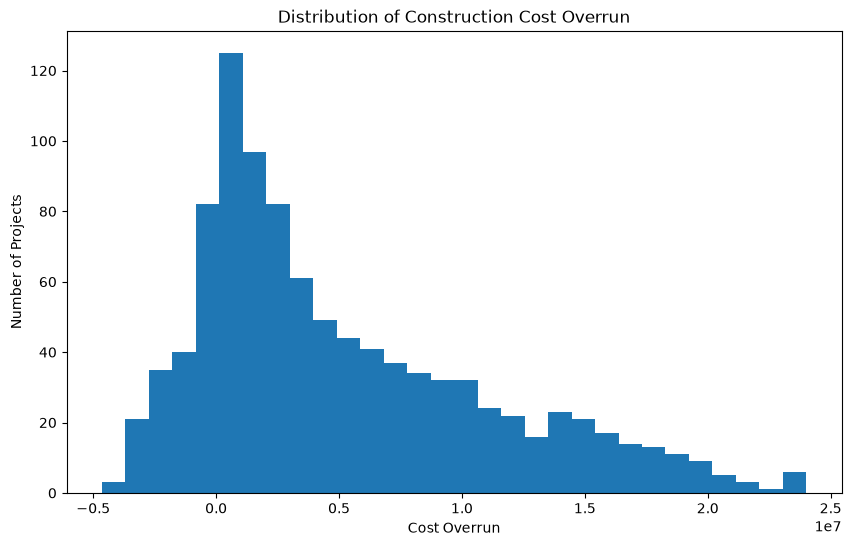

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df['Cost_Overrun'], bins=30)

plt.xlabel('Cost Overrun')
plt.ylabel('Number of Projects')
plt.title('Distribution of Construction Cost Overrun')

plt.show()

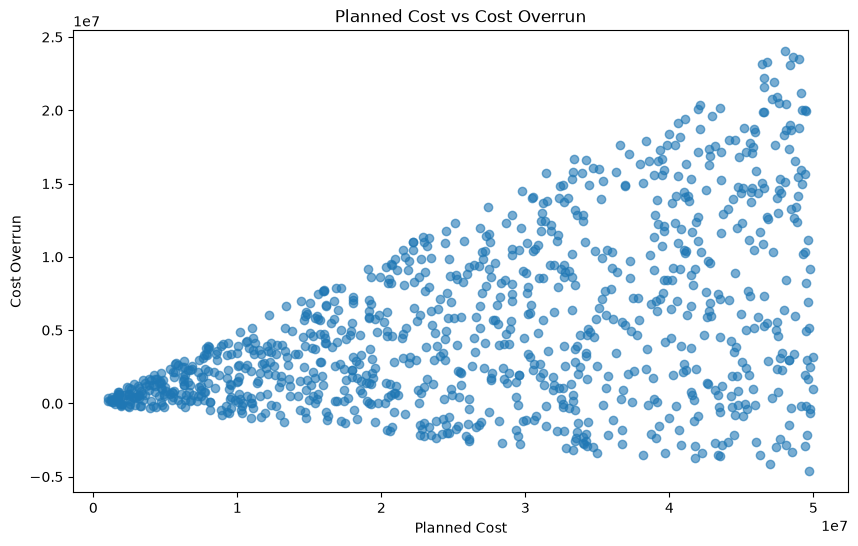

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(df['Planned_Cost'], df['Cost_Overrun'], alpha=0.6)

plt.xlabel('Planned Cost')
plt.ylabel('Cost Overrun')
plt.title('Planned Cost vs Cost Overrun')

plt.show()

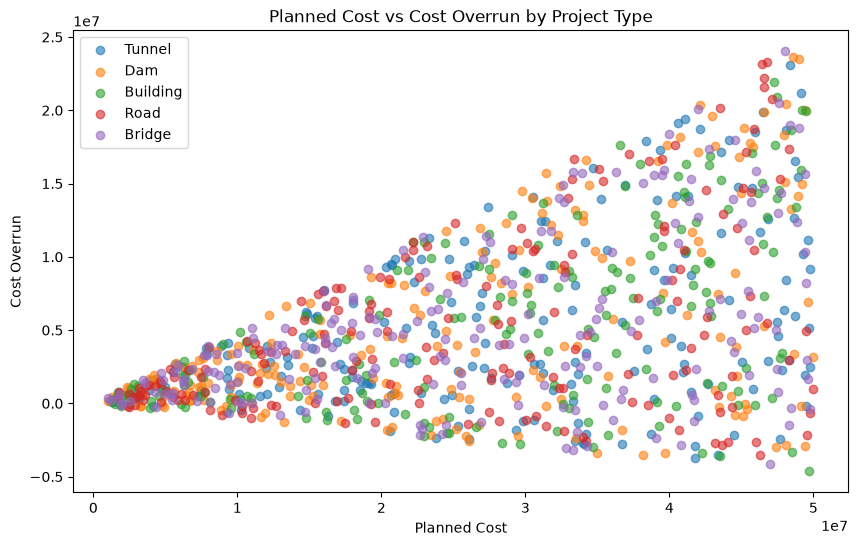

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for project_type in df['Project_Type'].unique():
    subset = df[df['Project_Type'] == project_type]
    plt.scatter(
        subset['Planned_Cost'],
        subset['Cost_Overrun'],
        alpha=0.6,
        label=project_type
    )

plt.xlabel('Planned Cost')
plt.ylabel('Cost Overrun')
plt.title('Planned Cost vs Cost Overrun by Project Type')
plt.legend()
plt.show()

In [27]:
df['Overrun_Percentage'] = (
    df['Cost_Overrun'] / df['Planned_Cost']
) * 100

df['Overrun_Percentage'].describe()

count    1000.000000
mean       19.497531
std        17.203890
min        -9.960797
25%         4.583182
50%        19.201875
75%        34.273585
max        49.973462
Name: Overrun_Percentage, dtype: float64

In [28]:
df[['Planned_Cost', 'Cost_Overrun', 'Overrun_Percentage']].head(20)

,Planned_Cost,Cost_Overrun,Overrun_Percentage
0,12260784,2.793720e+06,22.785819
1,2369277,1.137777e+06,48.022117
2,23299783,-1.607656e+06,-6.899877
3,24499306,4.970354e+06,20.287736
4,1749971,5.793670e+05,33.107237
5,16711072,6.978281e+06,41.758428
6,47109273,3.558336e+05,0.755337
7,42776934,1.625532e+07,38.000209
8,25527188,5.912716e+06,23.162425
9,5460276,7.531479e+05,13.793221


In [29]:
df.corr(numeric_only=True)['Cost_Overrun'].sort_values(ascending=False)

Cost_Overrun             1.000000
Overrun_Percentage       0.770414
Actual_Cost              0.711835
Planned_Cost             0.479780
Load_Bearing_Capacity    0.067201
Air_Quality_Index        0.066589
Material_Usage           0.054209
Safety_Risk_Score        0.038492
Humidity                 0.027677
Anomaly_Detected         0.025696
Completion_Percentage    0.024296
Image_Analysis_Score     0.014355
Vibration_Level          0.003856
Planned_Duration         0.001905
Temperature             -0.011097
Crack_Width             -0.013586
Actual_Duration         -0.015062
Energy_Consumption      -0.023577
Equipment_Utilization   -0.027748
Labor_Hours             -0.033200
Accident_Count          -0.036419
Schedule_Deviation      -0.040288
Name: Cost_Overrun, dtype: float64

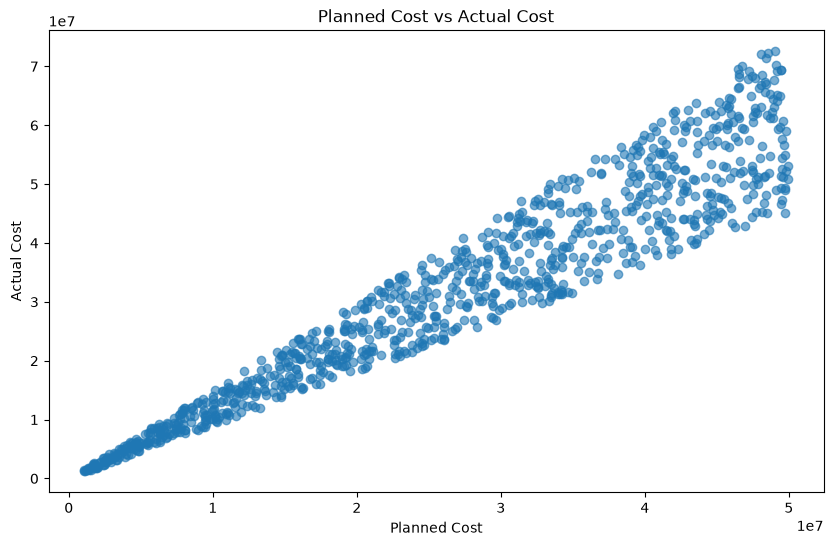

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Planned_Cost'], df['Actual_Cost'], alpha=0.6)

plt.xlabel('Planned Cost')
plt.ylabel('Actual Cost')
plt.title('Planned Cost vs Actual Cost')

plt.show()

In [31]:
df['Actual_to_Planned_Ratio'] = (
    df['Actual_Cost'] / df['Planned_Cost']
)

df['Actual_to_Planned_Ratio'].describe()

count    1000.000000
mean        1.194975
std         0.172039
min         0.900392
25%         1.045832
50%         1.192019
75%         1.342736
max         1.499735
Name: Actual_to_Planned_Ratio, dtype: float64

In [32]:
df[['Planned_Cost', 'Actual_Cost', 'Cost_Overrun',
    'Overrun_Percentage', 'Actual_to_Planned_Ratio']].head(20)

,Planned_Cost,Actual_Cost,Cost_Overrun,Overrun_Percentage,Actual_to_Planned_Ratio
0,12260784,1.505450e+07,2.793720e+06,22.785819,1.227858
1,2369277,3.507054e+06,1.137777e+06,48.022117,1.480221
2,23299783,2.169213e+07,-1.607656e+06,-6.899877,0.931001
3,24499306,2.946966e+07,4.970354e+06,20.287736,1.202877
4,1749971,2.329338e+06,5.793670e+05,33.107237,1.331072
5,16711072,2.368935e+07,6.978281e+06,41.758428,1.417584
6,47109273,4.746511e+07,3.558336e+05,0.755337,1.007553
7,42776934,5.903226e+07,1.625532e+07,38.000209,1.380002
8,25527188,3.143990e+07,5.912716e+06,23.162425,1.231624
9,5460276,6.213424e+06,7.531479e+05,13.793221,1.137932


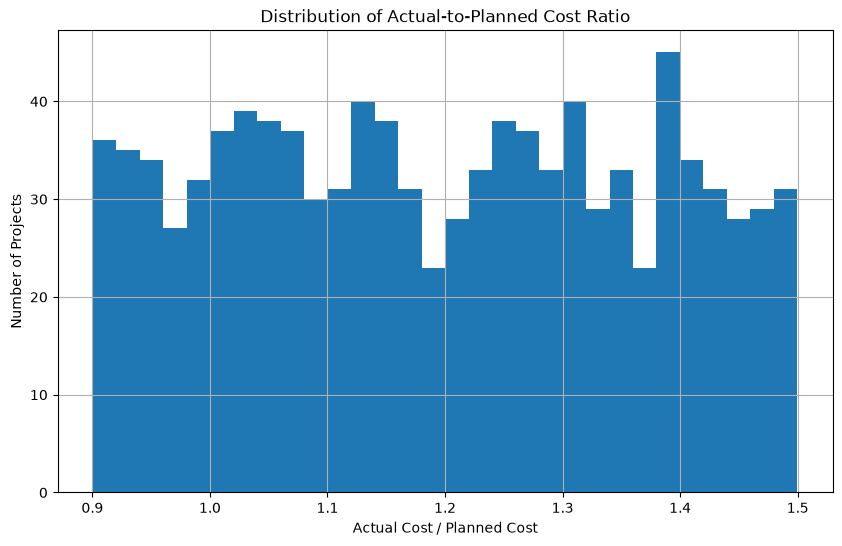

In [33]:
df['Actual_to_Planned_Ratio'].hist(bins=30, figsize=(10,6))

plt.xlabel('Actual Cost / Planned Cost')
plt.ylabel('Number of Projects')
plt.title('Distribution of Actual-to-Planned Cost Ratio')

plt.show()

In [34]:
df.columns

Index(['Project_ID', 'Project_Type', 'Location', 'Start_Date', 'End_Date',
       'Planned_Cost', 'Actual_Cost', 'Cost_Overrun', 'Planned_Duration',
       'Actual_Duration', 'Schedule_Deviation', 'Vibration_Level',
       'Crack_Width', 'Load_Bearing_Capacity', 'Temperature', 'Humidity',
       'Weather_Condition', 'Air_Quality_Index', 'Energy_Consumption',
       'Material_Usage', 'Labor_Hours', 'Equipment_Utilization',
       'Accident_Count', 'Safety_Risk_Score', 'Image_Analysis_Score',
       'Anomaly_Detected', 'Completion_Percentage', 'Risk_Level',
       'Overrun_Percentage', 'Actual_to_Planned_Ratio'],
      dtype='str')

In [35]:
features = [
    'Project_Type',
    'Location',
    'Planned_Cost',
    'Planned_Duration'
]

X = df[features]
y = df['Cost_Overrun']

X.head()

,Project_Type,Location,Planned_Cost,Planned_Duration
0,Tunnel,Houston,12260784,699
1,Dam,Houston,2369277,269
2,Building,Houston,23299783,899
3,Dam,Houston,24499306,809
4,Dam,Seattle,1749971,354


In [36]:
X.shape, y.shape

((1000, 4), (1000,))

In [37]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Project_Type      1000 non-null   str  
 1   Location          1000 non-null   str  
 2   Planned_Cost      1000 non-null   int64
 3   Planned_Duration  1000 non-null   int64
dtypes: int64(2), str(2)
memory usage: 44.5 KB


In [38]:
y.describe()

count    1.000000e+03
mean     5.125992e+06
std      5.931350e+06
min     -4.648579e+06
25%      5.810661e+05
50%      3.326817e+06
75%      8.665132e+06
max      2.401229e+07
Name: Cost_Overrun, dtype: float64

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (800, 4)
Testing features: (200, 4)
Training target: (800,)
Testing target: (200,)


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'Project_Type',
    'Location'
]

numeric_features = [
    'Planned_Cost',
    'Planned_Duration'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (800, 12)
Testing data after preprocessing: (200, 12)


In [42]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train_processed, y_train)

y_pred_lr = model_lr.predict(X_test_processed)

print("Model trained successfully.")

Model trained successfully.


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
MAE : 4200981.605587519
RMSE: 5477267.628886961
R²  : 0.08548571533398486


In [44]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1
)

model_rf.fit(X_train_processed, y_train)

y_pred_rf = model_rf.predict(X_test_processed)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [45]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
MAE : 4031903.228923725
RMSE: 5486851.878459686
R²  : 0.08228243870855345


In [46]:
candidate_features = [
    'Planned_Cost',
    'Planned_Duration',
    'Vibration_Level',
    'Crack_Width',
    'Load_Bearing_Capacity',
    'Temperature',
    'Humidity',
    'Air_Quality_Index',
    'Energy_Consumption',
    'Material_Usage',
    'Labor_Hours',
    'Equipment_Utilization',
    'Accident_Count',
    'Safety_Risk_Score',
    'Image_Analysis_Score',
    'Anomaly_Detected'
]

corr = df[candidate_features + ['Cost_Overrun']].corr()['Cost_Overrun'] \
    .sort_values(ascending=False)

print(corr)

Cost_Overrun             1.000000
Planned_Cost             0.479780
Load_Bearing_Capacity    0.067201
Air_Quality_Index        0.066589
Material_Usage           0.054209
Safety_Risk_Score        0.038492
Humidity                 0.027677
Anomaly_Detected         0.025696
Image_Analysis_Score     0.014355
Vibration_Level          0.003856
Planned_Duration         0.001905
Temperature             -0.011097
Crack_Width             -0.013586
Energy_Consumption      -0.023577
Equipment_Utilization   -0.027748
Labor_Hours             -0.033200
Accident_Count          -0.036419
Name: Cost_Overrun, dtype: float64


In [47]:
important_features = [
    'Planned_Cost',
    'Planned_Duration',
    'Vibration_Level',
    'Crack_Width',
    'Load_Bearing_Capacity',
    'Temperature',
    'Humidity',
    'Air_Quality_Index',
    'Energy_Consumption',
    'Material_Usage',
    'Labor_Hours',
    'Equipment_Utilization',
    'Accident_Count',
    'Safety_Risk_Score',
    'Image_Analysis_Score',
    'Anomaly_Detected',
    'Cost_Overrun'
]

corr_matrix = df[important_features].corr()

print(corr_matrix.round(2))

                       Planned_Cost  Planned_Duration  Vibration_Level  \
Planned_Cost                   1.00             -0.00             0.04   
Planned_Duration              -0.00              1.00             0.02   
Vibration_Level                0.04              0.02             1.00   
Crack_Width                   -0.04              0.00            -0.00   
Load_Bearing_Capacity          0.08              0.01            -0.01   
Temperature                    0.04             -0.06            -0.03   
Humidity                       0.02              0.07             0.04   
Air_Quality_Index              0.00             -0.04            -0.03   
Energy_Consumption             0.03              0.04            -0.01   
Material_Usage                 0.07             -0.03            -0.01   
Labor_Hours                   -0.02              0.02            -0.04   
Equipment_Utilization          0.01              0.02             0.01   
Accident_Count                -0.02   

In [48]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_gb.fit(X_train_processed, y_train)

y_pred_gb = model_gb.predict(X_test_processed)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [49]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("------------------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
------------------------
MAE : 4070966.5799614633
RMSE: 5547660.01858623
R²  : 0.06182847799682256


In [50]:
important_features = [
    'Planned_Cost',
    'Planned_Duration',
    'Vibration_Level',
    'Crack_Width',
    'Load_Bearing_Capacity',
    'Temperature',
    'Humidity',
    'Air_Quality_Index',
    'Energy_Consumption',
    'Material_Usage',
    'Labor_Hours',
    'Equipment_Utilization',
    'Accident_Count',
    'Safety_Risk_Score',
    'Image_Analysis_Score',
    'Anomaly_Detected',
    'Cost_Overrun'
]

corr_matrix = df[important_features].corr()

print(corr_matrix.round(2))

                       Planned_Cost  Planned_Duration  Vibration_Level  \
Planned_Cost                   1.00             -0.00             0.04   
Planned_Duration              -0.00              1.00             0.02   
Vibration_Level                0.04              0.02             1.00   
Crack_Width                   -0.04              0.00            -0.00   
Load_Bearing_Capacity          0.08              0.01            -0.01   
Temperature                    0.04             -0.06            -0.03   
Humidity                       0.02              0.07             0.04   
Air_Quality_Index              0.00             -0.04            -0.03   
Energy_Consumption             0.03              0.04            -0.01   
Material_Usage                 0.07             -0.03            -0.01   
Labor_Hours                   -0.02              0.02            -0.04   
Equipment_Utilization          0.01              0.02             0.01   
Accident_Count                -0.02   

In [51]:
features_expanded = [
    'Project_Type',
    'Location',
    'Planned_Cost',
    'Planned_Duration',
    'Vibration_Level',
    'Crack_Width',
    'Load_Bearing_Capacity',
    'Temperature',
    'Humidity',
    'Air_Quality_Index',
    'Energy_Consumption',
    'Material_Usage',
    'Labor_Hours',
    'Equipment_Utilization',
    'Accident_Count',
    'Safety_Risk_Score',
    'Image_Analysis_Score',
    'Anomaly_Detected'
]

X_expanded = df[features_expanded]
y = df['Cost_Overrun']

print(X_expanded.shape)

(1000, 18)


In [52]:
from sklearn.model_selection import train_test_split

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_expanded,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_exp.shape)
print("X_test :", X_test_exp.shape)
print("y_train:", y_train_exp.shape)
print("y_test :", y_test_exp.shape)

X_train: (800, 18)
X_test : (200, 18)
y_train: (800,)
y_test : (200,)


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features_exp = [
    'Project_Type',
    'Location'
]

numeric_features_exp = [
    'Planned_Cost',
    'Planned_Duration',
    'Vibration_Level',
    'Crack_Width',
    'Load_Bearing_Capacity',
    'Temperature',
    'Humidity',
    'Air_Quality_Index',
    'Energy_Consumption',
    'Material_Usage',
    'Labor_Hours',
    'Equipment_Utilization',
    'Accident_Count',
    'Safety_Risk_Score',
    'Image_Analysis_Score',
    'Anomaly_Detected'
]

preprocessor_exp = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_exp),
        ('num', 'passthrough', numeric_features_exp)
    ]
)

X_train_exp_processed = preprocessor_exp.fit_transform(X_train_exp)
X_test_exp_processed = preprocessor_exp.transform(X_test_exp)

print("Training shape:", X_train_exp_processed.shape)
print("Testing shape :", X_test_exp_processed.shape)

Training shape: (800, 26)
Testing shape : (200, 26)


In [54]:
print(preprocessor_exp.named_transformers_['cat'].get_feature_names_out())

['Project_Type_Bridge' 'Project_Type_Building' 'Project_Type_Dam'
 'Project_Type_Road' 'Project_Type_Tunnel' 'Location_Chicago'
 'Location_Houston' 'Location_Los Angeles' 'Location_New York'
 'Location_Seattle']


In [55]:
model_gb_exp = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_gb_exp.fit(X_train_exp_processed, y_train_exp)

y_pred_gb_exp = model_gb_exp.predict(X_test_exp_processed)

print("Expanded Gradient Boosting trained successfully.")

Expanded Gradient Boosting trained successfully.


In [56]:
mae_gb_exp = mean_absolute_error(y_test_exp, y_pred_gb_exp)

rmse_gb_exp = np.sqrt(
    mean_squared_error(y_test_exp, y_pred_gb_exp)
)

r2_gb_exp = r2_score(y_test_exp, y_pred_gb_exp)

print("Expanded Gradient Boosting Results")
print("----------------------------------")
print("MAE :", mae_gb_exp)
print("RMSE:", rmse_gb_exp)
print("R²  :", r2_gb_exp)

Expanded Gradient Boosting Results
----------------------------------
MAE : 4366249.293491222
RMSE: 5853279.017921793
R²  : -0.04438595686088487


In [57]:
df[['Planned_Cost', 'Actual_Cost', 'Cost_Overrun']].head(20)

,Planned_Cost,Actual_Cost,Cost_Overrun
0,12260784,1.505450e+07,2.793720e+06
1,2369277,3.507054e+06,1.137777e+06
2,23299783,2.169213e+07,-1.607656e+06
3,24499306,2.946966e+07,4.970354e+06
4,1749971,2.329338e+06,5.793670e+05
5,16711072,2.368935e+07,6.978281e+06
6,47109273,4.746511e+07,3.558336e+05
7,42776934,5.903226e+07,1.625532e+07
8,25527188,3.143990e+07,5.912716e+06
9,5460276,6.213424e+06,7.531479e+05


In [58]:
df['Overrun_Percentage'] = (
    df['Cost_Overrun'] / df['Planned_Cost']
) * 100

print(df['Overrun_Percentage'].describe())

count    1000.000000
mean       19.497531
std        17.203890
min        -9.960797
25%         4.583182
50%        19.201875
75%        34.273585
max        49.973462
Name: Overrun_Percentage, dtype: float64


In [59]:
ratio_corr = df[
    important_features[:-1] + ['Overrun_Percentage']
].corr()['Overrun_Percentage'].sort_values(ascending=False)

print(ratio_corr.round(3))

Overrun_Percentage       1.000
Air_Quality_Index        0.050
Image_Analysis_Score     0.047
Humidity                 0.020
Load_Bearing_Capacity    0.016
Crack_Width              0.015
Material_Usage           0.011
Anomaly_Detected         0.000
Equipment_Utilization   -0.002
Planned_Duration        -0.004
Safety_Risk_Score       -0.005
Planned_Cost            -0.010
Vibration_Level         -0.010
Temperature             -0.023
Accident_Count          -0.032
Energy_Consumption      -0.057
Labor_Hours             -0.070
Name: Overrun_Percentage, dtype: float64


In [60]:
df.groupby('Project_Type')['Overrun_Percentage'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

,mean,median,std,min,max
Project_Type,,,,,
Bridge,20.04,19.76,16.37,-9.62,49.97
Building,18.32,19.77,16.93,-9.59,49.74
Dam,20.18,19.43,17.93,-9.96,49.93
Road,19.82,19.27,17.84,-9.50,49.86
Tunnel,19.06,17.88,17.06,-9.88,49.01


In [61]:
df.groupby('Location')['Overrun_Percentage'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

,mean,median,std,min,max
Location,,,,,
Chicago,19.03,17.85,17.72,-9.96,49.86
Houston,20.84,21.81,16.74,-9.59,49.93
Los Angeles,18.03,16.94,17.55,-9.88,49.83
New York,19.60,18.08,17.58,-9.68,48.82
Seattle,20.09,20.63,16.43,-9.27,49.97
